# 03 · The sizing paradigm: MDF versus all-at-once on a toy, and what the choice costs

Tutorial 00 stated that this code is an all-at-once (SAND) formulation. This notebook makes that concrete on a toy
VTOL sized three ways: a classic weight loop, an MDF optimization (outer optimizer around the converged loop), and the
all-at-once NLP the repository uses. Then it covers what all-at-once demands in return (smoothness, scaling, starting
points) and what it gives you for free (multipliers, growth factors, infeasibility certificates).

**In this notebook**
1. A toy battery-electric VTOL, and the weight loop.
2. MDF: an outer optimizer over the converged loop, with finite-difference gradients.
3. All-at-once: mass as a variable, closure as an equality; same answer, far fewer evaluations.
4. When no aircraft closes: a diverging loop versus an infeasibility certificate.
5. Multipliers as sensitivities; the weight growth factor.
6. Local optima and starting points, including a real one from the gearbox model.
7. How each idea appears in the Halo driver.

**Run time:** about 10 seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import scipy.optimize as so
g = 9.80665

## 1. The toy and the weight loop

A battery-electric VTOL carries 400 kg. Structure is 30 % of take-off mass; motors scale with hover power (5 kW/kg);
rotors with disk area (4 kg/m²); the battery holds 2 min of hover plus a cruise, at 180 Wh/kg with 80 % usable. Hover
power comes from momentum theory with a figure of merit. Every part depends on take-off mass, which is the sum of the parts.

In [2]:
def hover_power_W(mass_kg, area_disk_m2, figure_of_merit=0.7, density_kg_m3=1.225):
    thrust_N = mass_kg * g
    return thrust_N**1.5 / np.sqrt(2 * density_kg_m3 * area_disk_m2) / figure_of_merit

def parts_kg(mass_takeoff_kg, area_disk_m2, range_m=50e3, payload_kg=400.0):
    """Every part as a function of the take-off mass (numbers or symbols)."""
    power_hover_W = hover_power_W(mass_takeoff_kg, area_disk_m2)
    power_cruise_W = mass_takeoff_kg * g * 50.0 / 12.0 / 0.8          # 50 m/s, L/D 12, propulsive efficiency 0.8
    energy_J = power_hover_W * 120 + power_cruise_W * range_m / 50.0
    return dict(payload=payload_kg,
                structure=0.30 * mass_takeoff_kg,
                motors=power_hover_W / 5000.0,
                rotors=4.0 * area_disk_m2,
                battery=energy_J / (180 * 3600.0) / 0.8)

def weight_loop(area_disk_m2, range_m=50e3, guess_kg=1000.0, tolerance_kg=1e-9, max_passes=500):
    """Fixed-point iteration m <- sum(parts(m)). Returns the history of guesses."""
    history = [guess_kg]
    for _ in range(max_passes):
        history.append(sum(parts_kg(history[-1], area_disk_m2, range_m).values()))
        if abs(history[-1] - history[-2]) < tolerance_kg or history[-1] > 1e9:
            break
    return history

history = weight_loop(10.0)
print(f"disk 10 m2: take-off mass {history[-1]:.4f} kg after {len(history) - 1} passes")

disk 10 m2: take-off mass 904.5033 kg after 45 passes


That is a **multidisciplinary analysis (MDA)** for one design: a Gauss-Seidel fixed point on the single coupling
variable $m_\text{TO}$. Its convergence rate is the derivative of the map, $\partial(\sum m_i)/\partial m_\text{TO}$:
fast when it is small, slow near 1, divergent above 1 (the "snowball").

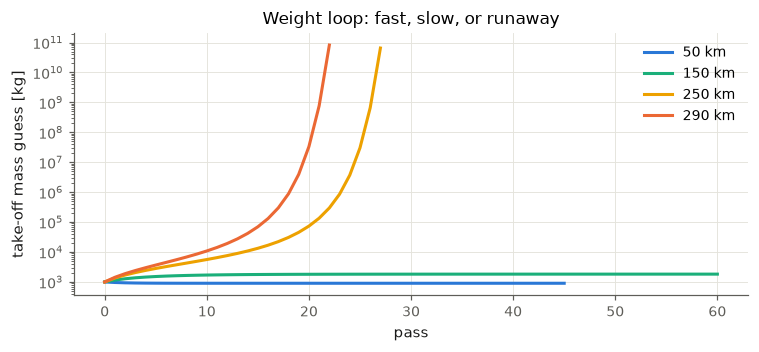

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.3))
for range_km, color in ((50, blue), (150, aqua), (250, yellow), (290, orange)):
    h = weight_loop(10.0, range_km * 1e3, max_passes=60)
    ax.plot(h, color=color, lw=2, label=f"{range_km} km")
ax.set(yscale="log", xlabel="pass", ylabel="take-off mass guess [kg]", title="Weight loop: fast, slow, or runaway")
ax.legend(); plt.tight_layout(); plt.show()

## 2. MDF: an outer optimizer around the converged loop

To find the best disk area the MDF way, an outer optimizer calls the converged MDA at each candidate design and
differentiates through it by finite differences. Count the work:

In [4]:
calls = {"part evaluations": 0, "loops": 0}

def closed_mass_kg(area_disk_m2):
    calls["loops"] += 1
    h = weight_loop(float(area_disk_m2))
    calls["part evaluations"] += len(h) - 1
    return h[-1]

mdf = so.minimize(lambda a: closed_mass_kg(a[0]), x0=[10.0], method="SLSQP", bounds=[(1.0, 60.0)],
                  options=dict(ftol=1e-10))
print(f"MDF optimum: disk {mdf.x[0]:.3f} m2, take-off mass {mdf.fun:.4f} kg")
print(f"work: {calls['loops']} converged loops = {calls['part evaluations']} evaluations of the parts")

MDF optimum: disk 11.882 m2, take-off mass 902.0986 kg
work: 12 converged loops = 520 evaluations of the parts


## 3. All-at-once: the formulation this repository uses

Make $m_\text{TO}$ a **variable**, write closure as an **equality constraint**, and let IPOPT find the closed, optimal design
in one solve. This is the line `mass_takeoff_kg / total.mass == 1` in every sizing driver.

In [5]:
def size_all_at_once(range_m=50e3, payload_kg=400.0, verbose=False):
    opti = asb.Opti()
    mass_takeoff_kg = opti.variable(init_guess=1000.0, scale=1000.0, lower_bound=100.0)
    area_disk_m2 = opti.variable(init_guess=10.0, scale=10.0, lower_bound=1.0, upper_bound=60.0)
    parts = parts_kg(mass_takeoff_kg, area_disk_m2, range_m, payload_kg)
    closure = opti.subject_to(mass_takeoff_kg / sum(parts.values()) == 1)      # normalized closure
    opti.minimize(mass_takeoff_kg / 1000.0)                                     # objective of order one
    solution = opti.solve(verbose=verbose)
    return opti, solution, mass_takeoff_kg, area_disk_m2, parts, closure

opti, sol, m, A, parts, closure = size_all_at_once()
iterations = sol.stats()["iter_count"]
print(f"all-at-once optimum: disk {sol.value(A):.3f} m2, take-off mass {sol.value(m):.4f} kg in {iterations} IPOPT iterations")
for name, kg in parts.items():
    print(f"   {name:<10}{sol.value(kg):8.1f} kg")
check("MDF and all-at-once agree on the optimum", abs(sol.value(m) - mdf.fun) < 1e-3 and abs(sol.value(A) - mdf.x[0]) < 1e-2)
check("the all-at-once design is closed: the weight loop at its disk area gives the same mass",
      abs(weight_loop(sol.value(A))[-1] - sol.value(m)) < 1e-6)

all-at-once optimum: disk 11.882 m2, take-off mass 902.0986 kg in 5 IPOPT iterations
   payload      400.0 kg
   structure    270.6 kg
   motors        44.1 kg
   rotors        47.5 kg
   battery      139.9 kg
PASS  MDF and all-at-once agree on the optimum
PASS  the all-at-once design is closed: the weight loop at its disk area gives the same mass


Same answer. The differences that matter at scale:

| | MDF (section 2) | All-at-once (section 3) |
|---|---|---|
| Work per optimizer iteration | a converged MDA, plus one more per design variable for finite differences | one evaluation of explicit expressions and their exact derivatives |
| Gradient accuracy | limited by the MDA tolerance and the FD step | exact (AD) |
| Intermediate iterates | always closed (feasible) | closed only at convergence |
| Coupling variables | hidden inside the MDA | explicit, visible, bounded, scalable |
| With 300 design and state variables | thousands of MDAs | a few hundred IPOPT iterations of a sparse system |

The Halo problem couples far more than mass. The bus power balance couples generator torque, battery current and motor
demand; momentum theory couples rotor speed, thrust and induced power; the SOC chain couples every segment's battery
current; the thermal model couples cooling drag to thrust. Each would be another nested loop in an MDF code. Here each is
one more variable and one more equality.

## 4. When no aircraft closes

At 290 km the loop's map has slope above 1 and the guesses run away. MDF has no closed design to give its optimizer.
All-at-once returns an infeasibility status:

In [6]:
runaway = weight_loop(10.0, 290e3, max_passes=60)
print(f"weight loop at 290 km: {runaway[-1]:.3g} kg after {len(runaway) - 1} passes, still growing")
try:
    size_all_at_once(range_m=290e3)
    print("solved?!")
except RuntimeError as error:
    status = str(error)[str(error).find("return_status"):][:60]
    print("all-at-once at 290 km:", status)

weight loop at 290 km: 8.21e+10 kg after 22 passes, still growing
all-at-once at 290 km: return_status is 'Infeasible_Problem_Detected'


The status is informative, not a crash: the requirements admit no closed design within the model. In the Halo driver,
this is how "250 kt is infeasible with these engines" was established (plan 017 in `docs/decisions/`).

## 5. Multipliers are sensitivities

The multiplier of the closure equality and of any margin is the derivative of the optimal objective with respect to
that constraint's right-hand side. Two uses run through the repository.

**What a requirement costs.** Add a footprint limit on disk area as a normalized margin, read its multiplier, and compare with a
re-solve:

In [7]:
def toy_with_footprint(area_max_m2):
    opti = asb.Opti()
    m_ = opti.variable(init_guess=1000.0, scale=1000.0, lower_bound=100.0)
    A_ = opti.variable(init_guess=5.0, scale=10.0, lower_bound=1.0)
    opti.subject_to(m_ / sum(parts_kg(m_, A_).values()) == 1)
    footprint = opti.subject_to((area_max_m2 - A_) / area_max_m2 >= 0)     # a normalized margin (core/margins.py)
    opti.minimize(m_ / 1000)
    s = opti.solve(verbose=False)
    return s.value(m_), s.value(footprint)

mass_kg, lam = toy_with_footprint(8.0)
mass_tight_kg, _ = toy_with_footprint(8.0 * (1 - 0.001))      # 0.1 % more margin required
print(f"multiplier {lam:.4f} t per unit margin -> predicts +{1000 * lam * 0.001:.4f} kg for 0.1 % tighter")
print(f"re-solved: +{mass_tight_kg - mass_kg:.4f} kg")
check("the multiplier predicts the re-solved change within 2 %",
      abs(1000 * lam * 0.001 - (mass_tight_kg - mass_kg)) < 0.02 * (mass_tight_kg - mass_kg))

multiplier 0.0667 t per unit margin -> predicts +0.0667 kg for 0.1 % tighter


re-solved: +0.0668 kg
PASS  the multiplier predicts the re-solved change within 2 %


**The weight growth factor.** $\mathrm{d}m_\text{TO}/\mathrm{d}m_\text{payload}$: how many kilograms of take-off mass one
more kilogram of payload costs once everything resizes. Here by re-solving (the Halo's is about 3; any added kilogram
anywhere costs about three at take-off):

In [8]:
_, s1, m1, *_ = size_all_at_once(payload_kg=400.0)
_, s2, m2, *_ = size_all_at_once(payload_kg=401.0)
growth = s2.value(m2) - s1.value(m1)
print(f"growth factor dMTOM/dpayload = {growth:.3f} kg/kg")
check("growth factor above 1 (every kg added costs more than a kg)", growth > 1)

growth factor dMTOM/dpayload = 2.255 kg/kg
PASS  growth factor above 1 (every kg added costs more than a kg)


## 6. Local optima and starting points

IPOPT converges to a KKT point near its start. A one-variable example with two valleys:

In [9]:
def two_valleys(x0):
    o = asb.Opti()
    x = o.variable(init_guess=x0)
    o.minimize((x**2 - 4)**2 + 0.5 * x)
    return o.solve(verbose=False).value(x)

for x0 in (-3.0, -0.5, 0.5, 3.0):
    print(f"start {x0:+.1f} -> x* = {two_valleys(x0):+.4f}")

start -3.0 -> x* = -2.0154
start -0.5 -> x* = -2.0154
start +0.5 -> x* = +1.9842
start +3.0 -> x* = +1.9842


A real case from the code: `GearStageModel` (`powertrain/components/gearbox.py`) turns a gear ratio into a number of
stages. Stages are integers; the model offers a smooth **staircase** (a sum of steep sigmoids, one step per stage) and a
**relaxed** softplus (a smooth max(1, x)). The staircase is closer to reality but every plateau is a local optimum for
anything that depends on the stage count:

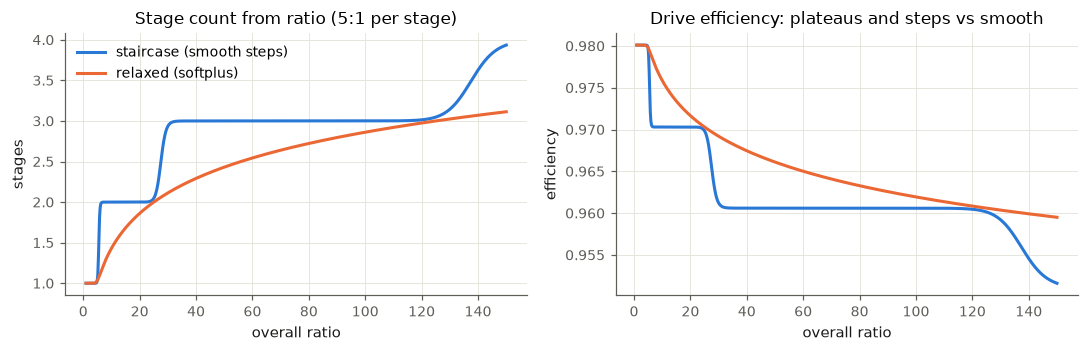

PASS  at the stage limit the staircase gives 1 + sigmoid(-3) = 1.047 stages


In [10]:
from aircraft_closure.powertrain.components.gearbox import GearStageModel
ratios = onp.linspace(1.0, 150.0, 1500)
staircase, relaxed = GearStageModel(staircase=True), GearStageModel(staircase=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
axes[0].plot(ratios, staircase.count_stages(ratios), color=blue, lw=2, label="staircase (smooth steps)")
axes[0].plot(ratios, relaxed.count_stages(ratios), color=orange, lw=2, label="relaxed (softplus)")
axes[0].set(xlabel="overall ratio", ylabel="stages", title="Stage count from ratio (5:1 per stage)")
axes[1].plot(ratios, staircase.efficiency(ratios), color=blue, lw=2)
axes[1].plot(ratios, relaxed.efficiency(ratios), color=orange, lw=2)
axes[1].set(xlabel="overall ratio", ylabel="efficiency", title="Drive efficiency: plateaus and steps vs smooth")
axes[0].legend(); plt.tight_layout(); plt.show()
check("at the stage limit the staircase gives 1 + sigmoid(-3) = 1.047 stages",
      abs(staircase.count_stages(5.0) - (1 + 1 / (1 + onp.exp(3)))) < 1e-9)

`solve_halo_sizing` handles this explicitly: with the staircase it solves from its own start *and* from the relaxed
solution, and keeps the better of the two complete solves. More generally, `solve_halo_sizing_multistart` holds an ordered list
of starting points (simpler precursor problems, perturbed designs, a generic guess), each an independent complete solve, and
records which one succeeded. Nothing is iterated to a fixed point: every coupling lives inside each solve.

## 7. Where each idea appears in the Halo driver

In [11]:
import inspect, examples.halo_sizing as hs
source = inspect.getsource(hs)
for label, pattern in (("closure equality", "mass_takeoff_kg / total.mass == 1"),
                       ("objective in tonnes", "mass_takeoff_kg / 1000"),
                       ("explicit variable scales", "scale="),
                       ("normalized margins", "margin_above(" ),
                       ("smooth maximum", "softmax"),
                       ("multistart entry point", "def solve_halo_sizing_multistart")):
    print(f"{label:<26} {source.count(pattern):4d} occurrence(s) of  {pattern!r}")
check("the Halo driver closes mass with the normalized equality", "mass_takeoff_kg / total.mass == 1" in source)

closure equality              1 occurrence(s) of  'mass_takeoff_kg / total.mass == 1'
objective in tonnes           1 occurrence(s) of  'mass_takeoff_kg / 1000'
explicit variable scales     21 occurrence(s) of  'scale='
normalized margins            8 occurrence(s) of  'margin_above('
smooth maximum                1 occurrence(s) of  'softmax'
multistart entry point        1 occurrence(s) of  'def solve_halo_sizing_multistart'
PASS  the Halo driver closes mass with the normalized equality


## Summary

- A weight loop is an MDA; wrapping it in an optimizer is MDF. All-at-once makes the coupling variable a design variable and the
  coupling equation a constraint, and lets IPOPT solve analysis and design together with exact derivatives.
- All-at-once is cheaper per iteration and exact, and reports infeasibility as a status, at the price of intermediate iterates that
  are not closed, and of needing smooth, scaled, well-started problems.
- Multipliers on normalized margins are sensitivities of take-off mass to each requirement; the growth factor is the same idea
  for payload.
- Local optima are handled with explicit, finite lists of complete solves from different starts.

## Check yourself

<details><summary>1. In MDF terms, what are the "disciplines" and "coupling variables" of the Halo problem, and where did the MDA go?</summary>

Disciplines: aerodynamics, rotor, powertrain components, weights, stability, thermal, mission. Coupling variables: take-off mass, bus voltage (through battery current), rotor speed and thrust, the battery share per point, generator torque, cooling drag, SOC and mass at each segment boundary. There is no MDA: each coupling is an Opti variable with an equality, and IPOPT drives all residuals to zero together.
</details>

<details><summary>2. An IPOPT iterate halfway through a Halo solve has <code>mass_takeoff_kg</code> = 7,000 kg but the parts add up to 7,300 kg. Is that a bug?</summary>

No. Equalities only hold at convergence in an all-at-once formulation (`inf_pr` in the log measures how far off they are). Only the converged solution is a closed aircraft.
</details>

<details><summary>3. Why would a growth factor below 1 be a red flag?</summary>

Adding payload must add at least that much mass, plus structure, energy and power to carry it. Below 1 means some part shrinks when the aircraft gets heavier: a modelling error or an active bound that should not be active.
</details>

In [12]:
check_summary()

6 of 6 checks passed
